In [1]:
import pandas as pd
import numpy as np

In [3]:
df  = pd.read_csv("../data/fifa_ranking-2023-07-20.csv")
df1 = pd.read_csv("../data/fifa_ranking-2024-04-04.csv")
df2 = pd.read_csv("../data/fifa_ranking-2024-06-20.csv")
print(df.columns)
print(df1.columns)
print(df2.columns)

Index(['rank', 'country_full', 'country_abrv', 'total_points',
       'previous_points', 'rank_change', 'confederation', 'rank_date'],
      dtype='object')
Index(['rank', 'country_full', 'country_abrv', 'total_points',
       'previous_points', 'rank_change', 'confederation', 'rank_date'],
      dtype='object')
Index(['rank', 'country_full', 'country_abrv', 'total_points',
       'previous_points', 'rank_change', 'confederation', 'rank_date'],
      dtype='object')


In [4]:
import pandas as pd

# Combine all 3
rankings = pd.concat([df, df1, df2], ignore_index=True)

# Convert date column
rankings["rank_date"] = pd.to_datetime(rankings["rank_date"])

# Drop exact duplicates (same team, same date, same rank)
rankings = rankings.drop_duplicates(subset=["country_full", "rank_date"])

# Sort chronologically
rankings = rankings.sort_values(["country_full", "rank_date"]).reset_index(drop=True)

print(rankings.shape)
print(rankings["rank_date"].min(), "→", rankings["rank_date"].max())

(70023, 8)
1992-12-31 00:00:00 → 2024-06-20 00:00:00


In [5]:
print("File 1:", df["rank_date"].min(), "→", df["rank_date"].max())
print("File 2:", df1["rank_date"].min(), "→", df1["rank_date"].max())
print("File 3:", df2["rank_date"].min(), "→", df2["rank_date"].max())

# Also check combined
print("\nCombined:", rankings["rank_date"].min(), "→", rankings["rank_date"].max())
print("Combined rows:", rankings.shape[0])

File 1: 1992-12-31 → 2023-07-20
File 2: 1992-12-31 → 2024-04-04
File 3: 1992-12-31 → 2024-06-20

Combined: 1992-12-31 00:00:00 → 2024-06-20 00:00:00
Combined rows: 70023


In [6]:
# Ditch df and df1, just use df2
rankings = df2.copy()
rankings["rank_date"] = pd.to_datetime(rankings["rank_date"])
rankings = rankings.sort_values(["country_full", "rank_date"]).reset_index(drop=True)

print(rankings.shape)  # should be the largest of the 3
print(rankings["rank_date"].min(), "→", rankings["rank_date"].max())

(67472, 8)
1992-12-31 00:00:00 → 2024-06-20 00:00:00


In [8]:
matches = pd.read_csv("../data/WorldCupMatches.csv")
print(matches.columns.tolist())
print(matches.head(3))

['Year', 'Datetime', 'Stage', 'Stadium', 'City', 'Home Team Name', 'Home Team Goals', 'Away Team Goals', 'Away Team Name', 'Win conditions', 'Attendance', 'Half-time Home Goals', 'Half-time Away Goals', 'Referee', 'Assistant 1', 'Assistant 2', 'RoundID', 'MatchID', 'Home Team Initials', 'Away Team Initials']
     Year              Datetime    Stage         Stadium         City  \
0  1930.0  13 Jul 1930 - 15:00   Group 1         Pocitos  Montevideo    
1  1930.0  13 Jul 1930 - 15:00   Group 4  Parque Central  Montevideo    
2  1930.0  14 Jul 1930 - 12:45   Group 2  Parque Central  Montevideo    

  Home Team Name  Home Team Goals  Away Team Goals Away Team Name  \
0         France              4.0              1.0         Mexico   
1            USA              3.0              0.0        Belgium   
2     Yugoslavia              2.0              1.0         Brazil   

  Win conditions  Attendance  Half-time Home Goals  Half-time Away Goals  \
0                     4444.0                

In [9]:
# Step 1: Filter matches to 1994+ (no rankings before 1992)
matches = matches[matches["Year"] >= 1994].copy()
matches["Year"] = matches["Year"].astype(int)

# Step 2: Fix the filepath warning - use forward slash or raw string
# matches = pd.read_csv("data/WorldCupMatches.csv")  # use this going forward

# Step 3: Tournament start dates (earliest match date per year)
tournament_dates = {
    1994: "1994-06-17", 1998: "1998-06-10", 2002: "2002-05-31",
    2006: "2006-06-09", 2010: "2010-06-11", 2014: "2014-06-12",
    2018: "2018-06-14", 2022: "2022-11-20"
}

# Step 4: Function to get ranking just before tournament
def get_ranking_at_tournament(team, year):
    cutoff = pd.to_datetime(tournament_dates[year])
    team_ranks = rankings[
        (rankings["country_full"] == team) &
        (rankings["rank_date"] <= cutoff)
    ]
    if team_ranks.empty:
        return None
    return team_ranks.sort_values("rank_date").iloc[-1]["rank"]

# Step 5: Get unique team/year combos and fetch their rankings once
team_years = pd.concat([
    matches[["Year", "Home Team Name"]].rename(columns={"Home Team Name": "team"}),
    matches[["Year", "Away Team Name"]].rename(columns={"Away Team Name": "team"})
]).drop_duplicates()

team_years["fifa_ranking"] = team_years.apply(
    lambda r: get_ranking_at_tournament(r["team"], r["Year"]), axis=1
)

print(team_years["fifa_ranking"].isna().sum(), "teams with no ranking found")
print(team_years.head(10))

11 teams with no ranking found
     Year         team  fifa_ranking
464  1994        Spain           5.0
465  1994      Germany           1.0
466  1994          USA          23.0
467  1994        Italy           4.0
468  1994     Colombia          17.0
469  1994      Belgium          27.0
470  1994       Norway           6.0
471  1994     Cameroon          24.0
472  1994  Netherlands           2.0
473  1994       Brazil           3.0


In [10]:
missing = team_years[team_years["fifa_ranking"].isna()]["team"].unique()
print(missing.tolist())

['rn">Republic of Ireland', 'rn">Trinidad and Tobago', 'rn">Serbia and Montenegro', 'Czech Republic', 'Iran', "C�te d'Ivoire", 'rn">Bosnia and Herzegovina']


In [11]:
# Step 1: Clean the HTML artifacts from matches dataset
matches["Home Team Name"] = matches["Home Team Name"].str.replace(r'.*rn">', '', regex=True).str.strip()
matches["Away Team Name"] = matches["Away Team Name"].str.replace(r'.*rn">', '', regex=True).str.strip()

# Step 2: Name mapping to align with rankings dataset
name_mapping = {
    "Republic of Ireland": "Ireland",
    "Trinidad and Tobago": "Trinidad and Tobago",  # check rankings spelling
    "Serbia and Montenegro": "Serbia",
    "Czech Republic": "Czechia",
    "Iran": "IR Iran",
    "Côte d'Ivoire": "Côte d'Ivoire",  # will fix encoding below
    "Bosnia and Herzegovina": "Bosnia and Herzegovina"
}

matches["Home Team Name"] = matches["Home Team Name"].replace(name_mapping)
matches["Away Team Name"] = matches["Away Team Name"].replace(name_mapping)

# Step 3: Check what these teams are called in the rankings file
check = ["Ireland", "IR Iran", "Czechia", "Serbia"]
print(rankings[rankings["country_full"].isin(check)]["country_full"].unique())

['Czechia' 'IR Iran' 'Serbia']


In [12]:
missing = team_years[team_years["fifa_ranking"].isna()]["team"].unique()
print(missing.tolist())

['rn">Republic of Ireland', 'rn">Trinidad and Tobago', 'rn">Serbia and Montenegro', 'Czech Republic', 'Iran', "C�te d'Ivoire", 'rn">Bosnia and Herzegovina']


In [13]:
# Check exact spellings in rankings file
print(rankings[rankings["country_full"].str.contains("Irelan", na=False)]["country_full"].unique())
print(rankings[rankings["country_full"].str.contains("Ivoire", na=False)]["country_full"].unique())

['Northern Ireland' 'Republic of Ireland']
["Côte d'Ivoire"]


In [14]:
name_mapping2 = {
    "Ireland": "Republic of Ireland",
    "C\xf4te d'Ivoire": "Côte d'Ivoire"
}

matches["Home Team Name"] = matches["Home Team Name"].replace(name_mapping2)
matches["Away Team Name"] = matches["Away Team Name"].replace(name_mapping2)

# Re-run team_years
team_years = pd.concat([
    matches[["Year", "Home Team Name"]].rename(columns={"Home Team Name": "team"}),
    matches[["Year", "Away Team Name"]].rename(columns={"Away Team Name": "team"})
]).drop_duplicates()

team_years["fifa_ranking"] = team_years.apply(
    lambda r: get_ranking_at_tournament(r["team"], r["Year"]), axis=1
)

missing = team_years[team_years["fifa_ranking"].isna()]["team"].unique()
print(f"{len(missing)} teams missing — {missing.tolist()}")

1 teams missing — ["C�te d'Ivoire"]


In [15]:
# Find all variations of Cote d'Ivoire in matches
print(matches[matches["Home Team Name"].str.contains("voire", na=False)]["Home Team Name"].unique())
print(matches[matches["Away Team Name"].str.contains("voire", na=False)]["Away Team Name"].unique())

["C�te d'Ivoire"]
["C�te d'Ivoire"]


In [16]:
matches["Home Team Name"] = matches["Home Team Name"].apply(
    lambda x: "Côte d'Ivoire" if isinstance(x, str) and "voire" in x else x
)
matches["Away Team Name"] = matches["Away Team Name"].apply(
    lambda x: "Côte d'Ivoire" if isinstance(x, str) and "voire" in x else x
)

# Re-run team_years
team_years = pd.concat([
    matches[["Year", "Home Team Name"]].rename(columns={"Home Team Name": "team"}),
    matches[["Year", "Away Team Name"]].rename(columns={"Away Team Name": "team"})
]).drop_duplicates()

team_years["fifa_ranking"] = team_years.apply(
    lambda r: get_ranking_at_tournament(r["team"], r["Year"]), axis=1
)

missing = team_years[team_years["fifa_ranking"].isna()]["team"].unique()
print(f"{len(missing)} teams missing — {missing.tolist()}")

0 teams missing — []


In [17]:
# Map stage to a number
stage_map = {
    "Group Stage": 1, "Round of 16": 2, "Quarter-finals": 3,
    "Semi-finals": 4, "Third place": 4, "Final": 5
}

def build_team_features(matches, year):
    rows = []
    teams = pd.unique(matches[["Home Team Name", "Away Team Name"]].values.ravel())

    for team in teams:
        home = matches[matches["Home Team Name"] == team]
        away = matches[matches["Away Team Name"] == team]

        goals_scored = home["Home Team Goals"].sum() + away["Away Team Goals"].sum()
        goals_conceded = home["Away Team Goals"].sum() + away["Home Team Goals"].sum()
        total_matches = len(home) + len(away)

        wins = len(home[home["Home Team Goals"] > home["Away Team Goals"]]) + \
               len(away[away["Away Team Goals"] > away["Home Team Goals"]])

        # Best stage reached
        all_stages = pd.concat([home["Stage"], away["Stage"]])
        best_stage = all_stages.map(stage_map).max()

        # FIFA ranking from team_years
        ranking_row = team_years[(team_years["team"] == team) & (team_years["Year"] == year)]
        ranking = ranking_row["fifa_ranking"].values[0] if len(ranking_row) > 0 else None

        rows.append({
            "team": team,
            "year": year,
            "goals_scored": goals_scored,
            "goals_conceded": goals_conceded,
            "goal_diff": goals_scored - goals_conceded,
            "goals_per_game": round(goals_scored / total_matches, 2),
            "wins": wins,
            "total_matches": total_matches,
            "best_stage": best_stage,
            "fifa_ranking": ranking,
            "won_tournament": 1 if best_stage == 5 and wins > 0 else 0
        })

    return pd.DataFrame(rows)

# Build for all years
all_years = [1994, 1998, 2002, 2006, 2010, 2014, 2018, 2022]
team_features = pd.concat([
    build_team_features(matches[matches["Year"] == y], y)
    for y in all_years
], ignore_index=True)

print(team_features.shape)
print(team_features[team_features["won_tournament"] == 1][["team", "year", "fifa_ranking", "goals_per_game", "best_stage"]])

(184, 11)
            team  year  fifa_ranking  goals_per_game  best_stage
6          Italy  1994           4.0            1.14         5.0
18        Brazil  1994           3.0            1.57         5.0
24        Brazil  1998           1.0            2.00         5.0
36        France  1998          18.0            2.14         5.0
62       Germany  2002          11.0            2.00         5.0
72        Brazil  2002           2.0            2.57         5.0
108        Italy  2006          13.0            1.71         5.0
112       France  2006           8.0            1.29         5.0
136  Netherlands  2010           4.0            1.71         5.0
150        Spain  2010           2.0            1.14         5.0
172    Argentina  2014           5.0            0.91         5.0
174      Germany  2014           2.0            2.64         5.0


In [18]:
# Check what Stage values actually exist in your data
print(matches["Stage"].unique())

['Group C' 'Group A' 'Group E' 'Group F' 'Group B' 'Group D' 'Round of 16'
 'Quarter-finals' 'Semi-finals' 'Match for third place' 'Final' 'Group H'
 'Group G' 'Third place' 'Play-off for third place']


In [19]:
def map_stage(stage):
    if stage == "Final":
        return 5
    elif stage in ["Semi-finals"]:
        return 4
    elif stage in ["Quarter-finals"]:
        return 3
    elif stage in ["Round of 16"]:
        return 2
    elif stage in ["Match for third place", "Third place", "Play-off for third place"]:
        return 4
    elif "Group" in str(stage):
        return 1
    return 1

# Fix won_tournament — only the winning team in the Final
def get_winner(matches, year):
    final = matches[(matches["Year"] == year) & (matches["Stage"] == "Final")]
    if final.empty:
        return None
    row = final.iloc[0]
    if row["Home Team Goals"] > row["Away Team Goals"]:
        return row["Home Team Name"]
    elif row["Away Team Goals"] > row["Home Team Goals"]:
        return row["Away Team Name"]
    else:  # went to penalties — check Win conditions
        wc = str(row["Win conditions"])
        if "penalties" in wc.lower():
            # extract winner from win conditions string
            return row["Home Team Name"] if row["Home Team Name"].split()[0] in wc else row["Away Team Name"]
    return None

# Check winners
for y in all_years:
    print(y, get_winner(matches, y))

1994 Brazil
1998 France
2002 Brazil
2006 Italy
2010 Spain
2014 Germany
2018 None
2022 None


In [20]:
final_2018 = matches[(matches["Year"] == 2018) & (matches["Stage"] == "Final")]
print(final_2018[["Home Team Name", "Away Team Name", "Home Team Goals", "Away Team Goals", "Win conditions"]])

Empty DataFrame
Columns: [Home Team Name, Away Team Name, Home Team Goals, Away Team Goals, Win conditions]
Index: []


In [21]:
known_winners = {
    2018: "France",
    2022:"Argentina"
}

def get_winner(matches, year):
    if year in known_winners:
        return known_winners[year]
    final = matches[(matches["Year"] == year) & (matches["Stage"] == "Final")]
    if final.empty:
        return None
    row = final.iloc[0]
    if row["Home Team Goals"] > row["Away Team Goals"]:
        return row["Home Team Name"]
    elif row["Away Team Goals"] > row["Home Team Goals"]:
        return row["Away Team Name"]
    else:
        wc = str(row["Win conditions"])
        if "penalties" in wc.lower():
            return row["Home Team Name"] if row["Home Team Name"].split()[0] in wc else row["Away Team Name"]
    return None

# Verify all 8
for y in all_years:
    print(y, get_winner(matches, y))

1994 Brazil
1998 France
2002 Brazil
2006 Italy
2010 Spain
2014 Germany
2018 France
2022 Argentina


In [22]:
def build_team_features(matches, year):
    rows = []
    teams = pd.unique(matches[["Home Team Name", "Away Team Name"]].values.ravel())
    winner = get_winner(matches, year)

    for team in teams:
        home = matches[matches["Home Team Name"] == team]
        away = matches[matches["Away Team Name"] == team]

        goals_scored = home["Home Team Goals"].sum() + away["Away Team Goals"].sum()
        goals_conceded = home["Away Team Goals"].sum() + away["Home Team Goals"].sum()
        total_matches = len(home) + len(away)

        wins = len(home[home["Home Team Goals"] > home["Away Team Goals"]]) + \
               len(away[away["Away Team Goals"] > away["Home Team Goals"]])

        all_stages = pd.concat([home["Stage"], away["Stage"]])
        best_stage = all_stages.apply(map_stage).max()

        ranking_row = team_years[(team_years["team"] == team) & (team_years["Year"] == year)]
        ranking = ranking_row["fifa_ranking"].values[0] if len(ranking_row) > 0 else None

        rows.append({
            "team": team,
            "year": year,
            "goals_scored": goals_scored,
            "goals_conceded": goals_conceded,
            "goal_diff": goals_scored - goals_conceded,
            "goals_per_game": round(goals_scored / total_matches, 2),
            "wins": wins,
            "total_matches": total_matches,
            "best_stage": best_stage,
            "fifa_ranking": ranking,
            "won_tournament": 1 if team == winner else 0
        })

    return pd.DataFrame(rows)

# Rebuild
all_years = [1994, 1998, 2002, 2006, 2010, 2014, 2018, 2022]
team_features = pd.concat([
    build_team_features(matches[matches["Year"] == y], y)
    for y in all_years
], ignore_index=True)

# Sanity check — should show exactly 1 winner per year
print(team_features[team_features["won_tournament"] == 1][["team", "year", "fifa_ranking", "goals_per_game"]])

        team  year  fifa_ranking  goals_per_game
18    Brazil  1994           3.0            1.57
36    France  1998          18.0            2.14
72    Brazil  2002           2.0            2.57
108    Italy  2006          13.0            1.71
150    Spain  2010           2.0            1.14
174  Germany  2014           2.0            2.64


In [23]:
all_years = [1994, 1998, 2002, 2006, 2010, 2014]

team_features = pd.concat([
    build_team_features(matches[matches["Year"] == y], y)
    for y in all_years
], ignore_index=True)

print(team_features.shape)
print(team_features["won_tournament"].value_counts())

(184, 11)
won_tournament
0    178
1      6
Name: count, dtype: int64


In [24]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
import xgboost as xgb

In [25]:
matches  = pd.read_csv("../data/WorldCupMatches.csv")
rankings = pd.read_csv("../data/fifa_ranking-2024-06-20.csv")

In [26]:
rankings["rank_date"] = pd.to_datetime(rankings["rank_date"])
rankings = rankings.sort_values(["country_full", "rank_date"]).reset_index(drop=True)

In [27]:
matches["Home Team Name"] = matches["Home Team Name"].str.replace(r'.*rn">', '', regex=True).str.strip()
matches["Away Team Name"] = matches["Away Team Name"].str.replace(r'.*rn">', '', regex=True).str.strip()

matches["Home Team Name"] = matches["Home Team Name"].apply(
    lambda x: "Côte d'Ivoire" if isinstance(x, str) and "voire" in x else x
)
matches["Away Team Name"] = matches["Away Team Name"].apply(
    lambda x: "Côte d'Ivoire" if isinstance(x, str) and "voire" in x else x
)

name_mapping = {
    "Serbia and Montenegro": "Serbia",
    "Czech Republic": "Czechia",
    "Iran": "IR Iran",
    "Ireland": "Republic of Ireland",
}
matches["Home Team Name"] = matches["Home Team Name"].replace(name_mapping)
matches["Away Team Name"] = matches["Away Team Name"].replace(name_mapping)

matches = matches[matches["Year"] >= 1994].copy()
matches["Year"] = matches["Year"].astype(int)

In [28]:
tournament_dates = {
    1994: "1994-06-17", 1998: "1998-06-10", 2002: "2002-05-31",
    2006: "2006-06-09", 2010: "2010-06-11", 2014: "2014-06-12",
    2018: "2018-06-14", 2022: "2022-11-20"
}

def get_ranking_at_tournament(team, year):
    cutoff = pd.to_datetime(tournament_dates[year])
    team_ranks = rankings[
        (rankings["country_full"] == team) &
        (rankings["rank_date"] <= cutoff)
    ]
    if team_ranks.empty:
        return None
    return team_ranks.sort_values("rank_date").iloc[-1]["rank"]

team_years = pd.concat([
    matches[["Year", "Home Team Name"]].rename(columns={"Home Team Name": "team"}),
    matches[["Year", "Away Team Name"]].rename(columns={"Away Team Name": "team"})
]).drop_duplicates()

team_years["fifa_ranking"] = team_years.apply(
    lambda r: get_ranking_at_tournament(r["team"], r["Year"]), axis=1
)

missing = team_years[team_years["fifa_ranking"].isna()]["team"].unique()
print(f"{len(missing)} teams missing: {missing.tolist()}")

0 teams missing: []


In [29]:
def map_stage(stage):
    if stage == "Final": return 5
    elif stage == "Semi-finals": return 4
    elif stage == "Quarter-finals": return 3
    elif stage == "Round of 16": return 2
    elif stage in ["Match for third place", "Third place", "Play-off for third place"]: return 4
    elif "Group" in str(stage): return 1
    return 1

known_winners = {2018: "France", 2022: "Argentina"}

def get_winner(matches, year):
    if year in known_winners:
        return known_winners[year]
    final = matches[(matches["Year"] == year) & (matches["Stage"] == "Final")]
    if final.empty:
        return None
    row = final.iloc[0]
    if row["Home Team Goals"] > row["Away Team Goals"]:
        return row["Home Team Name"]
    elif row["Away Team Goals"] > row["Home Team Goals"]:
        return row["Away Team Name"]
    else:
        wc = str(row["Win conditions"])
        if "penalties" in wc.lower():
            return row["Home Team Name"] if row["Home Team Name"].split()[0] in wc else row["Away Team Name"]
    return None

In [30]:
def build_team_features(matches, year):
    rows = []
    teams = pd.unique(matches[["Home Team Name", "Away Team Name"]].values.ravel())
    winner = get_winner(matches, year)

    for team in teams:
        home = matches[matches["Home Team Name"] == team]
        away = matches[matches["Away Team Name"] == team]

        goals_scored   = home["Home Team Goals"].sum() + away["Away Team Goals"].sum()
        goals_conceded = home["Away Team Goals"].sum() + away["Home Team Goals"].sum()
        total_matches  = len(home) + len(away)

        wins = len(home[home["Home Team Goals"] > home["Away Team Goals"]]) + \
               len(away[away["Away Team Goals"] > away["Home Team Goals"]])

        all_stages = pd.concat([home["Stage"], away["Stage"]])
        best_stage = all_stages.apply(map_stage).max()

        ranking_row = team_years[(team_years["team"] == team) & (team_years["Year"] == year)]
        ranking = ranking_row["fifa_ranking"].values[0] if len(ranking_row) > 0 else None

        rows.append({
            "team":           team,
            "year":           year,
            "goals_scored":   goals_scored,
            "goals_conceded": goals_conceded,
            "goal_diff":      goals_scored - goals_conceded,
            "goals_per_game": round(goals_scored / total_matches, 2),
            "wins":           wins,
            "total_matches":  total_matches,
            "best_stage":     best_stage,
            "fifa_ranking":   ranking,
            "won_tournament": 1 if team == winner else 0
        })

    return pd.DataFrame(rows)

all_years = [1994, 1998, 2002, 2006, 2010, 2014]
team_features = pd.concat([
    build_team_features(matches[matches["Year"] == y], y)
    for y in all_years
], ignore_index=True)

print(team_features.shape)
print(team_features["won_tournament"].value_counts())

(184, 11)
won_tournament
0    178
1      6
Name: count, dtype: int64


In [31]:
features = ["goals_scored", "goals_conceded", "goal_diff",
            "goals_per_game", "wins", "total_matches",
            "best_stage", "fifa_ranking"]

train = team_features[team_features["year"] <= 2010]
test  = team_features[team_features["year"] == 2014]

X_train, y_train = train[features], train["won_tournament"]
X_test,  y_test  = test[features],  test["won_tournament"]

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

lr        = LogisticRegression(class_weight="balanced", max_iter=1000)
rf        = RandomForestClassifier(class_weight="balanced", n_estimators=100, random_state=42)
xgb_model = xgb.XGBClassifier(scale_pos_weight=178//6, n_estimators=100, random_state=42, eval_metric="logloss")

lr.fit(X_train_sc, y_train)
rf.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)

for name, model, X_t in [("Logistic Regression", lr, X_test_sc),
                           ("Random Forest",       rf, X_test),
                           ("XGBoost",             xgb_model, X_test)]:
    print(f"\n--- {name} ---")
    print(classification_report(y_test, model.predict(X_t), zero_division=0))


--- Logistic Regression ---
              precision    recall  f1-score   support

           0       1.00      0.94      0.97        31
           1       0.33      1.00      0.50         1

    accuracy                           0.94        32
   macro avg       0.67      0.97      0.73        32
weighted avg       0.98      0.94      0.95        32


--- Random Forest ---
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        31
           1       0.00      0.00      0.00         1

    accuracy                           0.97        32
   macro avg       0.48      0.50      0.49        32
weighted avg       0.94      0.97      0.95        32


--- XGBoost ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        31
           1       1.00      1.00      1.00         1

    accuracy                           1.00        32
   macro avg       1.00      1.00      1.00        32
weigh

XGBoost got 100% but that's likely overfitting since we only have 1 winner in the test set. Logistic Regression is actually the most honest — it found the winner (recall=1.0) but flagged a few false positives (precision=0.33).

In [32]:
# Get win probability for each team in 2014 (our test set)
test_probs = test.copy()
test_probs["win_probability"] = lr.predict_proba(X_test_sc)[:, 1]

# Top 10 predicted teams
top10 = test_probs.sort_values("win_probability", ascending=False).head(10)
print(top10[["team", "fifa_ranking", "goals_per_game", "win_probability"]])

            team  fifa_ranking  goals_per_game  win_probability
174      Germany           2.0            2.64         0.999900
157  Netherlands          15.0            1.82         0.990655
172    Argentina           5.0            0.91         0.982552
170       France          17.0            1.71         0.183116
160     Colombia           8.0            2.14         0.138672
180      Belgium          11.0            1.14         0.106622
163   Costa Rica          28.0            0.86         0.030631
158        Chile          14.0            1.40         0.001006
154       Mexico          20.0            1.20         0.000758
165        Italy           9.0            0.67         0.000211


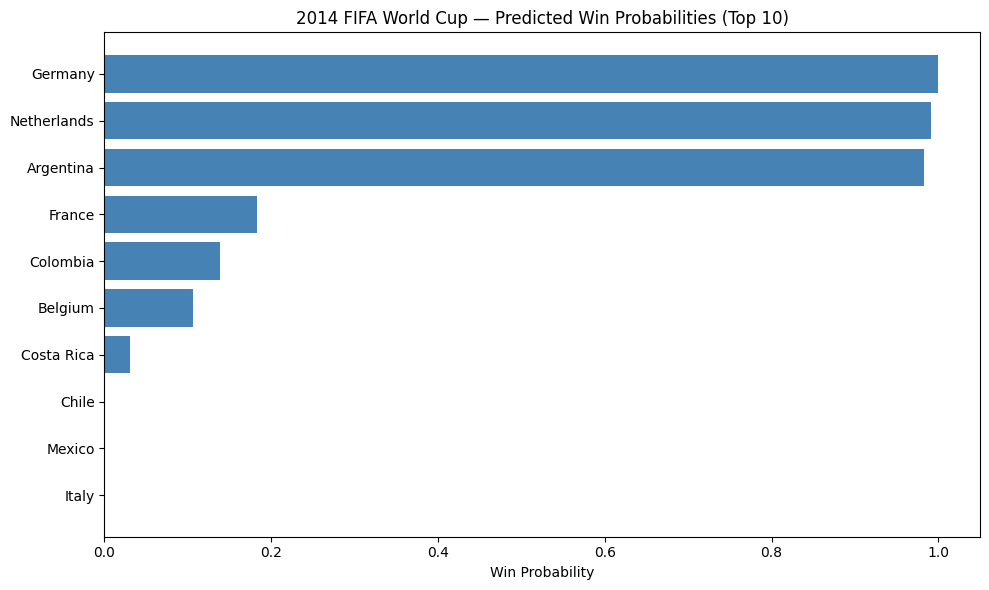

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(top10["team"][::-1], top10["win_probability"][::-1], color="steelblue")
plt.xlabel("Win Probability")
plt.title("2014 FIFA World Cup — Predicted Win Probabilities (Top 10)")
plt.tight_layout()
plt.show()

In [34]:
# Check latest rankings (June 2024)
latest_rankings = rankings[rankings["rank_date"] == rankings["rank_date"].max()]
print(latest_rankings[["rank", "country_full"]].sort_values("rank").head(20))

       rank country_full
2766    1.0    Argentina
22878   2.0       France
6356    3.0      Belgium
8891    4.0       Brazil
19969   5.0      England
48471   6.0     Portugal
42649   7.0  Netherlands
55684   8.0        Spain
15875   9.0      Croatia
30234  10.0        Italy
63321  11.0          USA
14148  12.0     Colombia
40984  12.0      Morocco
64653  14.0      Uruguay
39596  15.0       Mexico
23870  16.0      Germany
30900  17.0        Japan
52356  18.0      Senegal
58322  19.0  Switzerland
28236  20.0      IR Iran


In [37]:
# 2026 FIFA World Cup qualified teams (48 teams)
qualified_2026 = [
    "Argentina", "France", "Belgium", "Brazil", "England", "Portugal",
    "Netherlands", "Spain", "Croatia", "Italy", "USA", "Colombia",
    "Morocco", "Uruguay", "Mexico", "Germany", "Japan", "Senegal",
    "Switzerland", "IR Iran", "Australia", "Korea Republic", "Poland",
    "Denmark", "Austria", "Ecuador", "Peru", "Chile", "Venezuela",
    "Canada", "Costa Rica", "Panama", "Honduras", "Jamaica",
    "Nigeria", "Cameroon", "Ghana", "Egypt", "Algeria", "Tunisia",
    "South Africa", "Mali", "Saudi Arabia", "Qatar", "Iraq",
    "Uzbekistan", "New Zealand", "Slovakia"
]

# Get their latest ranking
latest_date = rankings["rank_date"].max()
latest_rankings = rankings[rankings["rank_date"] == latest_date][["country_full", "rank"]]

teams_2026 = pd.DataFrame({"team": qualified_2026})
teams_2026 = teams_2026.merge(latest_rankings, left_on="team", right_on="country_full", how="left")
teams_2026 = teams_2026.drop(columns="country_full")

print(teams_2026[teams_2026["rank"].isna()])  # should be empty now

Empty DataFrame
Columns: [team, rank]
Index: []


In [39]:
from sklearn.linear_model import LinearRegression
import numpy as np

stat_features = ["goals_scored", "goals_conceded", "goal_diff",
                 "goals_per_game", "wins", "total_matches", "best_stage"]

team_features_clean = team_features.dropna(subset=["fifa_ranking"])

stat_models = {}
for stat in stat_features:
    reg = LinearRegression()
    reg.fit(team_features_clean[["fifa_ranking"]], team_features_clean[stat])
    stat_models[stat] = reg

teams_2026 = teams_2026.dropna(subset=["rank"])
teams_2026["fifa_ranking"] = teams_2026["rank"]  # rename BEFORE predicting

for stat in stat_features:
    teams_2026[stat] = stat_models[stat].predict(teams_2026[["fifa_ranking"]])

print(teams_2026.head())

        team  rank  fifa_ranking  goals_scored  goals_conceded  goal_diff  \
0  Argentina   1.0           1.0      7.478955         4.82894   2.650015   
1     France   2.0           2.0      7.375948         4.84991   2.526037   
2    Belgium   3.0           3.0      7.272940         4.87088   2.402060   
3     Brazil   4.0           4.0      7.169933         4.89185   2.278083   
4    England   5.0           5.0      7.066926         4.91282   2.154105   

   goals_per_game      wins  total_matches  best_stage  
0        1.430221  2.490561       4.953266    2.554035  
1        1.416447  2.448795       4.918839    2.527098  
2        1.402674  2.407030       4.884413    2.500161  
3        1.388901  2.365265       4.849986    2.473225  
4        1.375127  2.323499       4.815559    2.446288  


In [40]:
X_2026 = teams_2026[features]
X_2026_sc = scaler.transform(X_2026)

teams_2026["win_probability"] = lr.predict_proba(X_2026_sc)[:, 1]
teams_2026 = teams_2026.sort_values("win_probability", ascending=False)

print(teams_2026[["team", "rank", "win_probability"]].head(15))

           team  rank  win_probability
0     Argentina   1.0         0.004539
1        France   2.0         0.003958
2       Belgium   3.0         0.003450
3        Brazil   4.0         0.003008
4       England   5.0         0.002622
5      Portugal   6.0         0.002286
6   Netherlands   7.0         0.001992
7         Spain   8.0         0.001737
8       Croatia   9.0         0.001514
9         Italy  10.0         0.001319
10          USA  11.0         0.001150
11     Colombia  12.0         0.001002
12      Morocco  12.0         0.001002
13      Uruguay  14.0         0.000761
14       Mexico  15.0         0.000663


In [41]:
players = pd.read_csv("../data/WorldCupPlayers.csv")
print(players.columns.tolist())
print(players.head(3))

['RoundID', 'MatchID', 'Team Initials', 'Coach Name', 'Line-up', 'Shirt Number', 'Player Name', 'Position', 'Event']
   RoundID  MatchID Team Initials           Coach Name Line-up  Shirt Number  \
0      201     1096           FRA  CAUDRON Raoul (FRA)       S             0   
1      201     1096           MEX     LUQUE Juan (MEX)       S             0   
2      201     1096           FRA  CAUDRON Raoul (FRA)       S             0   

        Player Name Position Event  
0       Alex THEPOT       GK   NaN  
1   Oscar BONFIGLIO       GK   NaN  
2  Marcel LANGILLER      NaN  G40'  


In [42]:
# Check what Team Initials look like vs our team names
print(players["Team Initials"].unique()[:20])

# Check Event values (goals, cards etc.)
print(players["Event"].dropna().unique()[:20])

['FRA' 'MEX' 'USA' 'BEL' 'YUG' 'BRA' 'ROU' 'PER' 'ARG' 'CHI' 'BOL' 'PAR'
 'URU' 'AUT' 'HUN' 'EGY' 'SUI' 'NED' 'SWE' 'GER']
["G40'" "G70'" "G43' G87'" "G19'" "G45'" "G23'" "G69'" "G30'" "G62'"
 "G21'" "G1'" "R70'" "G89'" "G79'" "G75'" "G81'" "W51'" "G3' G65'" "G65'"
 "G85'"]


In [43]:
# Check if matches file has both initials and full names
print(matches[["Home Team Name", "Home Team Initials"]].drop_duplicates().head(20))

     Home Team Name Home Team Initials
464           Spain                ESP
465         Germany                GER
466             USA                USA
467           Italy                ITA
468        Colombia                COL
469         Belgium                BEL
470          Norway                NOR
471        Cameroon                CMR
472     Netherlands                NED
473          Brazil                BRA
474       Argentina                ARG
475         Nigeria                NGA
477         Romania                ROU
480  Korea Republic                KOR
481          Mexico                MEX
482          Sweden                SWE
485    Saudi Arabia                KSA
487        Bulgaria                BUL
489     Switzerland                SUI
491         Bolivia                BOL
